# Exemple de transformation de shp en graphe
- Eventuellement les "explode" pour avoir les intersections
- Construire le graphe
- Joindre les noeuds "proches" (déterminer un seuil) si même problème qu'avant
- Vérifier que le graphe résultant ne comporte qu'une unique composante connexe
- Créer un nouveau notebook dans lequel a* est appliqué au graphe créé

In [1]:
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely import LineString
from utils.graph import count_components
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

In [2]:
gdf: GeoDataFrame = gpd.read_file("../data/fr/clip/route_rail_clip.shp")

In [ ]:
geom_count = {}

for idx, row in gdf.iterrows():
    if row.geometry.geom_type in geom_count:
        geom_count[row.geometry.geom_type] += 1
    else:
        geom_count[row.geometry.geom_type] = 0

print(geom_count)

{'LineString': 2360, 'MultiLineString': 2}


In [3]:
graph: dict[tuple[float, float], list[tuple[float, float]]] = defaultdict(list)

for idx, row in gdf.iterrows():
    geom = row.geometry

    if not isinstance(geom, LineString):
        continue

    line_points = [(x, y) for x, y in geom.coords]
    
    for idx, line_point in enumerate(line_points):

        if idx == 0:
            graph[(line_point[0], line_point[1])].append(line_points[idx+1])
            continue

        if idx == len(line_points)-1:
            graph[(line_point[0], line_point[1])].append(line_points[idx-1])
            continue

        graph[(line_point[0], line_point[1])].append(line_points[idx+1])
        graph[(line_point[0], line_point[1])].append(line_points[idx-1])


    # lines[(line_points[0], line_points[-1])] = line_points

for c in graph:
    print(f"Point: {c} | Voisins: {graph[c]}")

Point: (763961.0, 6736159.4) | Voisins: [(763951.0, 6736154.5), (763960.3, 6736079.4), (763964.6, 6736584.0)]
Point: (763951.0, 6736154.5) | Voisins: [(763890.5, 6736090.0), (763961.0, 6736159.4)]
Point: (763890.5, 6736090.0) | Voisins: [(763852.5161837856, 6736035.241366866), (763951.0, 6736154.5)]
Point: (763852.5161837856, 6736035.241366866) | Voisins: [(763890.5, 6736090.0)]
Point: (763960.3, 6736079.4) | Voisins: [(763958.2661331263, 6736035.555164935), (763961.0, 6736159.4)]
Point: (763958.2661331263, 6736035.555164935) | Voisins: [(763960.3, 6736079.4)]
Point: (763964.6, 6736584.0) | Voisins: [(763961.0, 6736159.4), (764149.4, 6736572.5), (763970.3, 6736658.9)]
Point: (764149.4, 6736572.5) | Voisins: [(763964.6, 6736584.0), (764192.7, 6736606.1)]
Point: (763967.1, 6736681.3) | Voisins: [(763970.3, 6736658.9), (764053.8, 6736747.2), (763960.8, 6736724.0)]
Point: (763970.3, 6736658.9) | Voisins: [(763964.6, 6736584.0), (763967.1, 6736681.3)]
Point: (768599.0, 6738663.2) | Voisins:

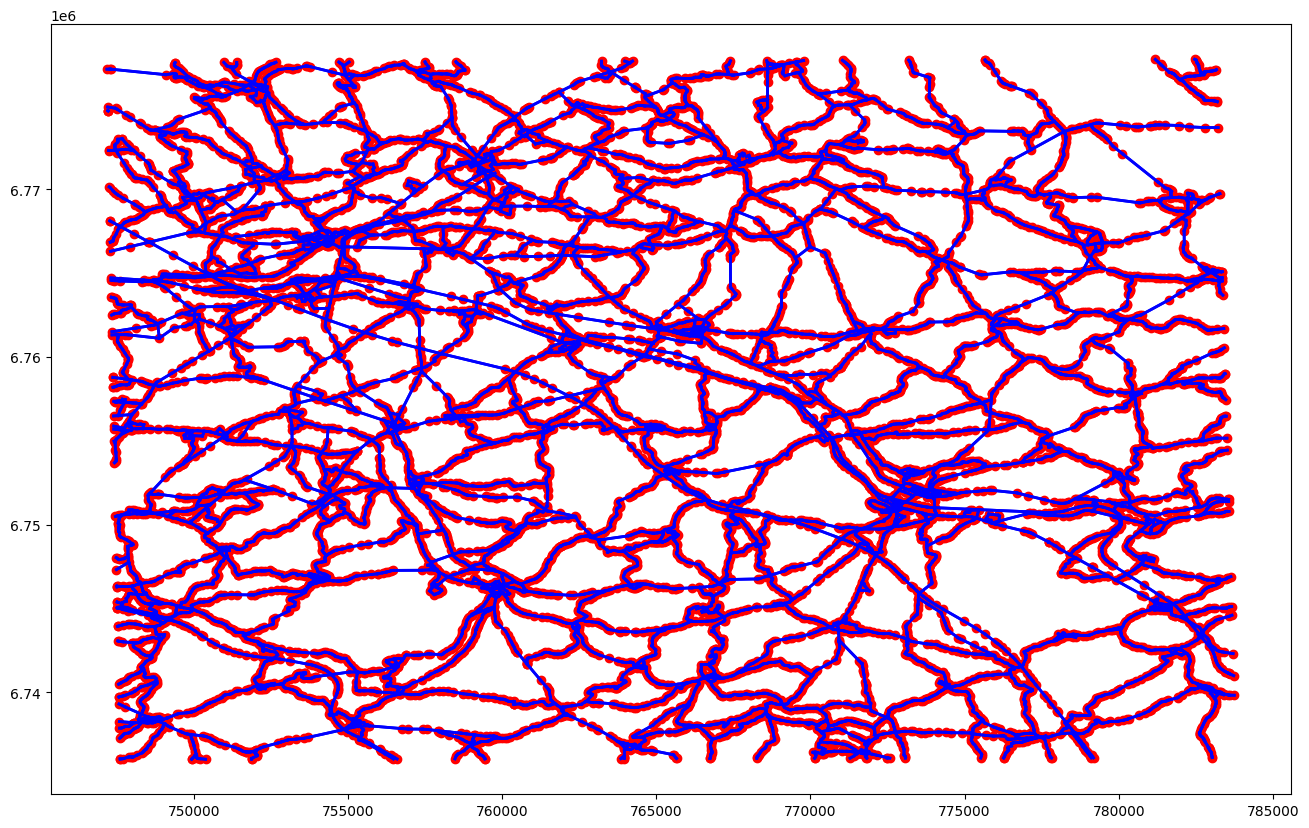

In [18]:
plt.figure(figsize=(16, 10))
x = [c[0] for c in graph]
y = [c[1] for c in graph]

plt.scatter(x, y, color="red")

for c in graph:
    for n in graph[c]:
        plt.plot([c[0], n[0]], [c[1], n[1]], color="blue", linewidth=2)

Le graphe est-il connexe ? 4
